# Baryonic Boost: how to choose a backend and compute $C_\ell$s

Hydrodynamic baryonic processes (AGN feedback, gas cooling, stellar winds) suppress the
nonlinear matter power spectrum at scales $k \gtrsim 0.1\,h\,\mathrm{Mpc}^{-1}$.
Ignoring this suppression biases cosmological parameter inference from weak lensing.

`cloelib` exposes a common interface for baryonic suppression through the
`BaryonBoostMixin` Protocol in `cloelib.cosmology.cosmology`.  Three ready-made
backends are provided:

| Backend | Class | Baryonic parameters |
|---------|-------|---------------------|
| **FLAMINGO** | `CAMBNonLinearFLAMINGOPerturbations` | `fgas_sigma`, `Mstar_sigma`, `jet_fraction` |
| **BACCOemu** | `BACCOemuNonLinearBaryonicPerturbations` | 7 baryonic params (e.g. `M_c`, `eta`, …) |
| **HMcode2020emu** | `HMemuNonLinearBaryonicPerturbations` | `log10TAGN` |

Each of these produces a `Perturbations`-compatible object whose
`matter_power_spectrum` already includes the baryonic correction.
You can therefore drop it into any `cloelib` tracer or likelihood with **no extra
wrapping needed**.

> **Goal of this tutorial**
>
> 1. Show how to instantiate each baryonic perturbation backend.
> 2. Compare the baryonic suppression $B(k, z) = P_\mathrm{hydro}/P_\mathrm{DMO}$.
> 3. Feed the result into photo-$z$ tracers and compute $C_\ell$s, comparing the
>    auto-power spectra with and without baryonic suppression.

In [3]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import integrate

sns.set_theme(style="ticks")
plt.rc("xtick", labelsize=16)
plt.rc("ytick", labelsize=16)
plt.rc("font", size=16)
plt.rc("axes", titlesize=18)
plt.rc("axes", labelsize=16)
plt.rc("lines", linewidth=2)
plt.rc("legend", fontsize=13)

# cloelib: cosmology and tracers
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import (
    HMemuLinearPerturbations,
    HMemuNonLinearPerturbations,
    HMemuNonLinearBaryonicPerturbations,
)
from cloelib.cosmology.baccoemu_cosmology import (
    BACCOemuLinearPerturbations,
    BACCOemuNonLinearPerturbations,
    BACCOemuNonLinearBaryonicPerturbations,
)
from cloelib.cosmology.FlamingoBaryonResponseEmulator_cosmology import (
    CAMBNonLinearFLAMINGOPerturbations,
)
from cloelib.cosmology.camb_cosmology import CAMBNonLinearPerturbations

from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint

## 1 — Cosmological background

We use a single `CAMBBackground` instance throughout, shared by all three backends.
The neutrino setup (`N_mnu=1`, `mnu=0.06 eV`) is required by HMcode2020emu.

In [12]:
zs = np.linspace(1e-4, 3.0, 100)

background = CAMBBackground(
    H0=70.0,
    Omega_cdm0=0.25,
    Omega_b0=0.05,
    Omega_k0=0.0,
    As=2.1e-9,
    ns=0.966,
    mnu=0.06,
    w0=-1.0,
    wa=0.0,
    gamma_MG=0.545,
    N_mnu=1,
)
print(f"h = {background.h:.4f},  Omega_m0 = {background.Omega_cdm0 + background.Omega_b0:.4f}")

h = 0.7000,  Omega_m0 = 0.3000


## 2 — Building baryonic Perturbations objects

### 2a — FLAMINGO (CAMB back-end)

`CAMBNonLinearFLAMINGOPerturbations` combines a standard CAMB nonlinear run with
the FLAMINGO emulator response.  The three baryonic parameters describe ICM gas
and AGN jet physics calibrated on the FLAMINGO hydrodynamical simulations:

- `fgas_sigma` — offset from the calibrated intracluster gas fraction (in σ).
- `Mstar_sigma` — offset from the stellar mass function (in σ).
- `jet_fraction` — fraction of AGN energy in collimated jets (0 = thermal, 1 = jets).

The FLAMINGO emulator is only valid for $k \leq 10^{1.5}\,h\,\mathrm{Mpc}^{-1}$
and $z \leq 3$.  `cloelib` clamps $k$ and returns suppression = 1 outside those
ranges automatically.

In [13]:
# FLAMINGO: calibration offsets at fiducial (0, 0) and AGN jet fraction = 0 (thermal)
pert_flamingo = CAMBNonLinearFLAMINGOPerturbations(
    background=background,
    redshifts=zs,
    fgas_sigma=0.0,    # 0σ offset from calibration gas fraction
    Mstar_sigma=0.0,   # 0σ offset from stellar mass function
    jet_fraction=0.0,  # pure thermal AGN feedback
)
print("FLAMINGO  k range:", pert_flamingo.k[[0, -1]], "h/Mpc")

TypeError: object.__init__() takes exactly one argument (the instance to initialize)

### 2b — BACCOemu

`BACCOemuNonLinearBaryonicPerturbations` runs the BACCOemu nonlinear emulator
**twice** at initialisation — once without baryons (DMO) and once with — and
stores $B(k,z) = P_\mathrm{baryon}/P_\mathrm{DMO}$ as a 2-D spline.

The 7 baryonic parameters follow the Aricò et al. (2021) baryonification model.
Default values (`None`) fall back to the emulator training-set defaults for the
selected `baryonic_model_name` (e.g. the Burger et al. 2025 best-fit).

In [15]:
# BACCOemu needs a linear-perturbations object first
linear_baccoemu = BACCOemuLinearPerturbations(background, zs)

# Baryonic perturbations: DMO + baryon ratio pre-computed at init
# All baryonic params are None → emulator's own defaults for "Burger2025"
pert_bacco = BACCOemuNonLinearBaryonicPerturbations(
    background=background,
    linearperturbations=linear_baccoemu,
    redshifts=zs,
    nonlinear_model_name="Arico2023",
    baryonic_model_name="Burger2025",
    # Optionally override individual baryonic params, e.g.:
    # M_c=13.0,  eta=0.3,  beta=0.5
)
print("BACCOemu  k range:", pert_bacco.k[[0, -1]], "h/Mpc")

AttributeError: 'BACCOemuNonLinearBaryonicPerturbations' object has no attribute 'emu'

### 2c — HMcode2020emu

`HMemuNonLinearBaryonicPerturbations` uses a single scalar parameter `log10TAGN`
(the log₁₀ of the AGN heating temperature in Kelvin) to capture the baryonic
feedback amplitude.  Typical values: 7.6 (weak feedback) – 8.3 (strong feedback).

Again, the DMO and baryonic spectra are both computed at initialisation and their
ratio is stored as a spline, so run-time overhead is negligible.

In [16]:
# HMcode2020emu needs a linear-perturbations object first
linear_hmemu = HMemuLinearPerturbations(background, zs)

# Baryonic perturbations with log10TAGN = 7.8 (moderate AGN feedback)
pert_hmcode = HMemuNonLinearBaryonicPerturbations(
    background=background,
    linearperturbations=linear_hmemu,
    redshifts=zs,
    log10TAGN=7.8,
)
print("HMcode2020  k range:", pert_hmcode.k[[0, -1]], "h/Mpc")

AttributeError: 'HMemuNonLinearBaryonicPerturbations' object has no attribute 'params_hm_emu'

## 3 — Comparing the baryonic suppression $B(k, z)$

All three classes expose `baryonic_suppression(zs, ks)` which returns
$B(k, z) = P_\mathrm{hydro}(k,z)/P_\mathrm{DMO}(k,z)$.
Below we compare them at three representative redshifts.

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/var/folders/b1/qymrqldd3fdbp79s76djm9240000gn/T/ipykernel_63589/3179976956.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax.semilogx(k_plot, B_hmcode,  label="HMcode2020 ($T_{\mathrm{AGN}}=10^{7.8}$ K)",


NameError: name 'pert_flamingo' is not defined

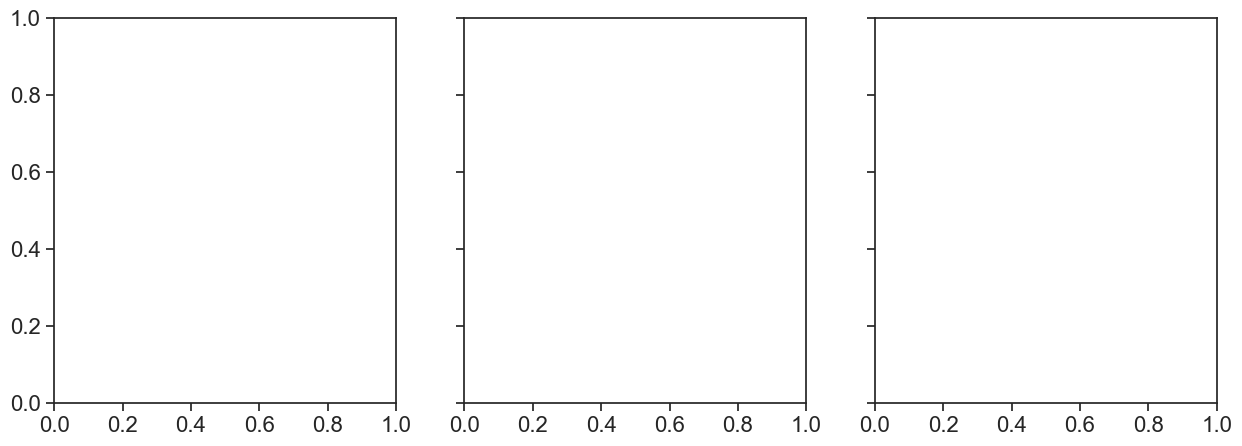

In [17]:
# Shared k grid for comparison (in h/Mpc, as used by cloelib internally)
k_plot = np.logspace(-2, 1.5, 200)

z_slices = [0.0, 0.5, 1.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

colors = {"FLAMINGO": "#e6194B", "BACCOemu": "#3cb44b", "HMcode2020": "#4363d8"}

for ax, z_val in zip(axes, z_slices):
    zv = np.array([z_val])

    # FLAMINGO: baryonic_suppression is called with k in h/Mpc (k_hunit=True)
    B_flamingo = pert_flamingo.baryonic_suppression(zv, k_plot, k_hunit=True)[0]

    # BACCOemu: k stored internally in h/Mpc, suppression also in h/Mpc
    k_bacco = k_plot * background.h / background.h  # no change; already h/Mpc
    B_bacco = pert_bacco.baryonic_suppression(
        zv, k_plot * background.h, k_hunit=False
    )[0]  # pass 1/Mpc (default)

    # HMcode2020: same convention
    B_hmcode = pert_hmcode.baryonic_suppression(
        zv, k_plot * background.h, k_hunit=False
    )[0]

    ax.semilogx(k_plot, B_flamingo, label="FLAMINGO", color=colors["FLAMINGO"])
    ax.semilogx(k_plot, B_bacco,   label="BACCOemu",  color=colors["BACCOemu"])
    ax.semilogx(k_plot, B_hmcode,  label="HMcode2020 ($T_{\mathrm{AGN}}=10^{7.8}$ K)",
                color=colors["HMcode2020"])

    ax.axhline(1.0, color="gray", lw=1, ls="--")
    ax.set_title(f"$z = {z_val}$")
    ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$")
    ax.tick_params(direction="in")

axes[0].set_ylabel(r"$B(k,z) = P_\mathrm{hydro}\,/\,P_\mathrm{DMO}$")
axes[0].legend(frameon=False, fontsize=12)
axes[0].set_ylim(0.7, 1.05)

plt.tight_layout()
plt.show()

## 4 — Effect on $P(k)$: baryon vs. DMO

Let's also look at the total matter power spectrum with and without baryonic
suppression at a single benchmark redshift $z = 0.5$.

In [18]:
# DMO baseline: CAMB nonlinear (no baryons)
pert_dmo = CAMBNonLinearPerturbations(background=background, redshifts=zs)

z_ref = np.array([0.5])

# Evaluation k (1/Mpc, the internal convention of cloelib)
k_eval = pert_dmo.k

Pk_dmo      = pert_dmo.matter_power_spectrum(z_ref, k_eval)[0]
Pk_flamingo = pert_flamingo.matter_power_spectrum(z_ref, k_eval)[0]
Pk_bacco    = pert_bacco.matter_power_spectrum(z_ref, k_eval)[0]
Pk_hmcode   = pert_hmcode.matter_power_spectrum(z_ref, k_eval)[0]

fig, ax = plt.subplots(figsize=(9, 5))

ax.loglog(k_eval, Pk_dmo,      "k--",  label="DMO (CAMB Takahashi)",  lw=2)
ax.loglog(k_eval, Pk_flamingo, color=colors["FLAMINGO"], label="FLAMINGO")
ax.loglog(k_eval, Pk_bacco,    color=colors["BACCOemu"],  label="BACCOemu")
ax.loglog(k_eval, Pk_hmcode,   color=colors["HMcode2020"], label="HMcode2020")

ax.set_xlabel(r"$k\;[\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$P(k)\;[\mathrm{Mpc}^3]$")
ax.set_title(r"Matter power spectrum at $z = 0.5$")
ax.legend(frameon=False)
ax.tick_params(direction="in")
plt.tight_layout()
plt.show()

Note: redshifts have been re-sorted (earliest first)


NameError: name 'pert_flamingo' is not defined

## 5 — Galaxy redshift distributions $n(z)$

We build simple toy redshift distributions for 6 tomographic bins to be used
for the tracer and $C_\ell$ computation in the next section.

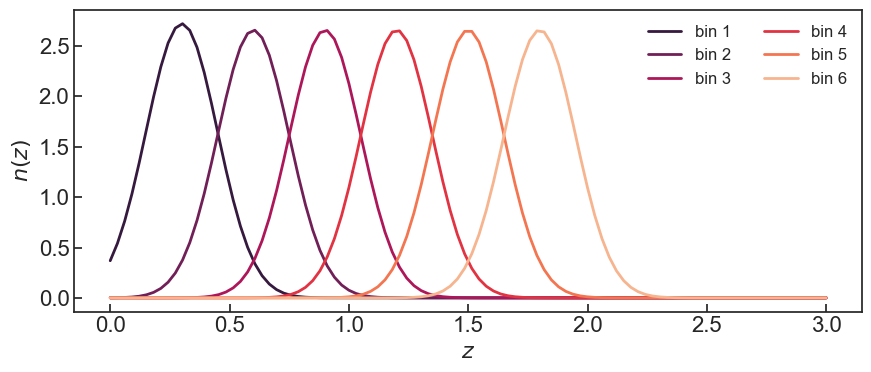

In [19]:
n_bins = 6
z_centers = np.linspace(0.3, 1.8, n_bins)
dndz_width = 0.15

# Gaussian n(z) for each bin, normalised to unit area
raw_nz = np.array([np.exp(-0.5 * ((zs - zc) / dndz_width) ** 2) for zc in z_centers])

# Normalise
dndz = np.array([nz / integrate.trapezoid(nz, zs) for nz in raw_nz])

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
palette = sns.color_palette("rocket", n_bins)
for i, (nz, color) in enumerate(zip(dndz, palette)):
    ax.plot(zs, nz, color=color, label=f"bin {i+1}")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$n(z)$")
ax.legend(frameon=False, ncol=2, fontsize=12)
ax.tick_params(direction="in")
plt.tight_layout()
plt.show()

## 6 — Tracers and $C_\ell$s

We build `ShearTracer` and `PositionsTracer` objects and compute the 3×2pt
angular power spectra.  The key point is that **every baryonic perturbations
object is a drop-in replacement** for the DMO one; the tracer and
`AngularTwoPoint` API is identical regardless of the backend.

> **Reading the $C_\ell$ dictionary**  
> `AngularTwoPoint.get_Cl(ells, 0, ks)` returns a dict keyed by
> `(probe1, probe2, bin_i, bin_j)`, e.g. `cells['SHE', 'SHE', 1, 1]`.
> `'SHE'` = cosmic shear (E-mode), `'POS'` = galaxy clustering.

In [23]:
nuisance_pos = {
    "b1_photo_poly0": 1.0, "b1_photo_poly1": 0.0,
    "b1_photo_poly2": 0.0, "b1_photo_poly3": 0.0,
    **{f"magnification_bias_{i}": 0.0 for i in range(1, n_bins + 1)},
    **{f"dz_pos_{i}": 0.0 for i in range(1, n_bins + 1)},
}
nuisance_she = {
    "AIA": 1.72, "CIA": 0.0134, "EtaIA": -0.41,
    **{f"multiplicative_bias_{i}": 0.0 for i in range(1, n_bins + 1)},
    **{f"dz_shear_{i}": 0.0 for i in range(1, n_bins + 1)},
}

ells = np.logspace(1.0, np.log10(3000), 60)


def build_cells(perturbations):
    """Return the 3x2pt Cell dict for a given perturbations object."""
    tracer_pos = PositionsTracer(
        perturbations=perturbations,
        dndz=dndz,
        z=zs,
        galaxy_bias_model="poly",
        nuisance_params=nuisance_pos,
    )
    tracer_she = ShearTracer(
        perturbations=perturbations,
        dndz=dndz,
        z=zs,
        nuisance_params=nuisance_she,
    )
    tp_gg = AngularTwoPoint(tracer_pos, tracer_pos)
    tp_gs = AngularTwoPoint(tracer_pos, tracer_she)
    tp_ss = AngularTwoPoint(tracer_she, tracer_she)
    return {
        **tp_gg.get_Cl(ells, 0, perturbations.k),
        **tp_gs.get_Cl(ells, 0, perturbations.k),
        **tp_ss.get_Cl(ells, 0, perturbations.k),
    }


print("Computing C_ells for all backends…")
cells_dmo      = build_cells(pert_dmo)
cells_flamingo = build_cells(pert_flamingo)
cells_bacco    = build_cells(pert_bacco)
cells_hmcode   = build_cells(pert_hmcode)
print("Done.")

Computing C_ells for all backends…


NameError: name 'pert_flamingo' is not defined

### 6a — Weak-lensing auto-spectra $C_\ell^{\gamma\gamma}$

The diagonal bins show the effect most clearly.  At high $\ell$ all baryonic
backends suppress power relative to DMO, with FLAMINGO typically showing the
largest suppression at $z \sim 0$ and BACCOemu the flattest response.

NameError: name 'cells_flamingo' is not defined

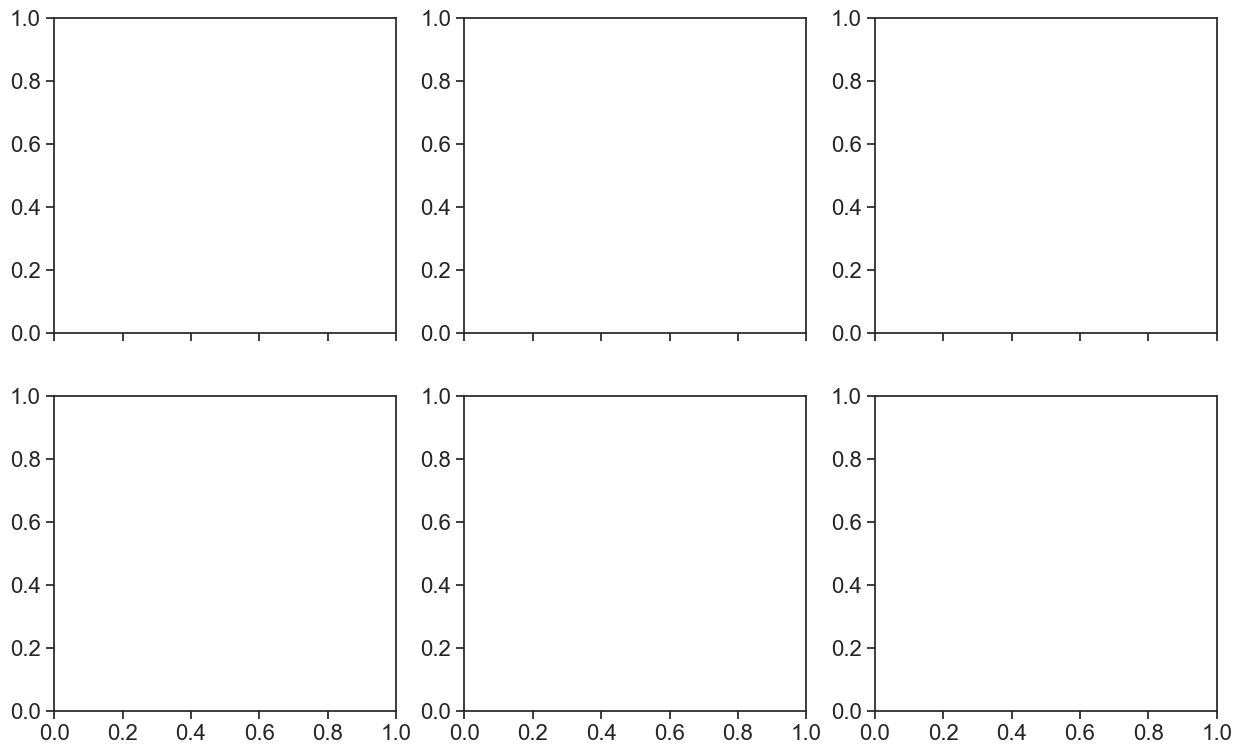

In [24]:

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
axes = axes.flatten()
palette_bins = sns.color_palette("mako", n_bins)

for idx, i in enumerate(range(1, n_bins + 1)):
    ax = axes[idx]
    key = ("SHE", "SHE", i, i)

    Cl_dmo      = cells_dmo[key][0, 0]
    Cl_flamingo = cells_flamingo[key][0, 0]
    Cl_bacco    = cells_bacco[key][0, 0]
    Cl_hmcode   = cells_hmcode[key][0, 0]
    ell         = cells_dmo[key].ell

    norm = ell * (2 * ell + 1)

    ax.loglog(ell, norm * Cl_dmo,      "k--",  lw=2,  label="DMO")
    ax.loglog(ell, norm * Cl_flamingo, color=colors["FLAMINGO"], label="FLAMINGO")
    ax.loglog(ell, norm * Cl_bacco,    color=colors["BACCOemu"],  label="BACCOemu")
    ax.loglog(ell, norm * Cl_hmcode,   color=colors["HMcode2020"], label="HMcode2020")

    ax.set_title(f"bin {i}  ($z_c = {z_centers[idx]:.1f}$)")
    ax.tick_params(direction="in")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$\ell(2\ell+1)\,C_\ell^{\gamma\gamma}$")

axes[0].legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

### 6b — Fractional baryonic effect $\Delta C_\ell / C_\ell^{\rm DMO}$

Plotting the fractional difference with respect to the DMO baseline makes the
effect of each backend immediately comparable.

NameError: name 'cells_flamingo' is not defined

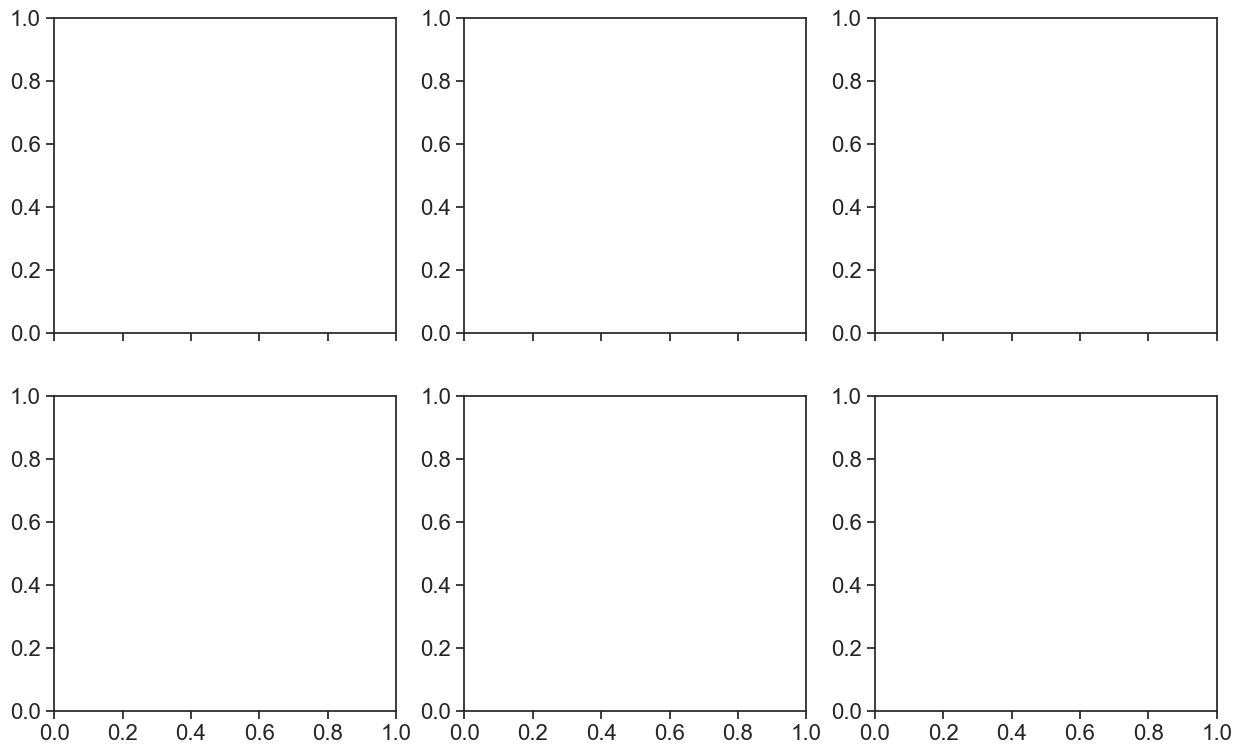

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
axes = axes.flatten()

for idx, i in enumerate(range(1, n_bins + 1)):
    ax = axes[idx]
    key = ("SHE", "SHE", i, i)

    Cl_dmo      = cells_dmo[key][0, 0]
    ell         = cells_dmo[key].ell

    for label, cells_dict, color in [
        ("FLAMINGO", cells_flamingo, colors["FLAMINGO"]),
        ("BACCOemu", cells_bacco,   colors["BACCOemu"]),
        ("HMcode2020", cells_hmcode, colors["HMcode2020"]),
    ]:
        Cl = cells_dict[key][0, 0]
        ax.semilogx(ell, (Cl - Cl_dmo) / Cl_dmo * 100, color=color, label=label)

    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_title(f"bin {i}  ($z_c = {z_centers[idx]:.1f}$)")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$\Delta C_\ell^{\gamma\gamma} / C_\ell^{\rm DMO}\,[\%]$")
    ax.tick_params(direction="in")

axes[0].legend(frameon=False, fontsize=12)
plt.suptitle(
    r"Fractional baryonic effect on $C_\ell^{\gamma\gamma}$ per tomographic bin",
    fontsize=15, y=1.01,
)
plt.tight_layout()
plt.show()

### 6c — Galaxy clustering auto-spectra $C_\ell^{gg}$

Baryonic effects on galaxy clustering are much smaller because the galaxy bias
suppresses the response, but they are non-zero at high $\ell$.

NameError: name 'n_bins' is not defined

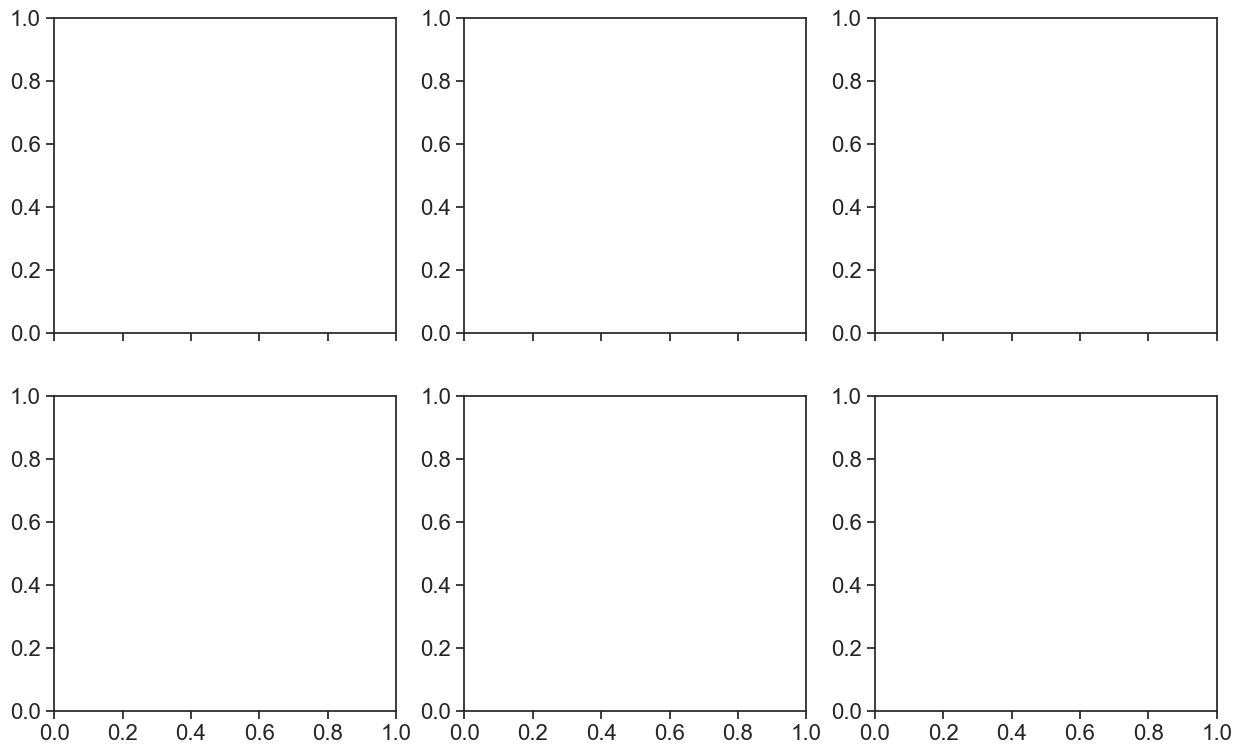

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
axes = axes.flatten()

for idx, i in enumerate(range(1, n_bins + 1)):
    ax = axes[idx]
    key = ("POS", "POS", i, i)

    Cl_dmo = cells_dmo[key]
    ell    = Cl_dmo.ell

    ax.loglog(ell, ell * (2 * ell + 1) * Cl_dmo,      "k--", lw=2, label="DMO")
    for label, cells_dict, color in [
        ("FLAMINGO", cells_flamingo, colors["FLAMINGO"]),
        ("BACCOemu", cells_bacco,   colors["BACCOemu"]),
        ("HMcode2020", cells_hmcode, colors["HMcode2020"]),
    ]:
        ax.loglog(ell, ell * (2 * ell + 1) * cells_dict[key], color=color, label=label)

    ax.set_title(f"bin {i}  ($z_c = {z_centers[idx]:.1f}$)")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$\ell(2\ell+1)\,C_\ell^{gg}$")
    ax.tick_params(direction="in")

axes[0].legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

## 7 — Implementing your own `BaryonBoostMixin`

If you want to plug in a custom baryonic suppression model (e.g. from a
simulation suite, a fitting formula, or another emulator), you only need to:

1. Subclass `BaryonBoostMixin` from `cloelib.cosmology.cosmology`.
2. Implement `baryonic_suppression(zs, ks, k_hunit=False)` returning an
   `np.ndarray` of shape `(nz, nk)`.
3. Combine with any base perturbation class using Python's MRO:
   `class MyPerturbations(MyBoostMixin, SomeNonLinearPerturbations)`.
4. Override `matter_power_spectrum` to call both parents.

```python
from cloelib.cosmology.cosmology import BaryonBoostMixin
from cloelib.cosmology.camb_cosmology import CAMBNonLinearPerturbations

class FittingFormulaBaryonMixin(BaryonBoostMixin):
    \"\"\"Baryon suppression from Mead et al. (2015) fitting formula.\"\"\"

    def __init__(self, A_baryon: float = 3.13, eta_baryon: float = 0.603):
        self.A_baryon = A_baryon
        self.eta_baryon = eta_baryon

    def baryonic_suppression(self, zs, ks, k_hunit=False):
        import numpy as np
        zs = np.atleast_1d(zs)
        ks = np.atleast_1d(ks)
        if k_hunit:
            ks = ks * self.background.h
        # Simple illustrative formula: B(k) = 1 - A*(k/10)^eta (z-independent)
        B = 1.0 - self.A_baryon * (ks / 10.0) ** self.eta_baryon
        return np.clip(B, 0.0, 1.0)[np.newaxis, :] * np.ones((len(zs), 1))


class CAMBFittingFormulaPerturbations(FittingFormulaBaryonMixin, CAMBNonLinearPerturbations):
    def __init__(self, background, redshifts, A_baryon=3.13, eta_baryon=0.603):
        CAMBNonLinearPerturbations.__init__(self, background, redshifts)
        FittingFormulaBaryonMixin.__init__(self, A_baryon, eta_baryon)

    def matter_power_spectrum(self, zs, ks, hubble_units=False, k_hunit=False):
        pk = CAMBNonLinearPerturbations.matter_power_spectrum(
            self, zs, ks, hubble_units=hubble_units, k_hunit=k_hunit
        )
        return pk * self.baryonic_suppression(zs, ks, k_hunit=k_hunit)
```

> **Important:** the `baryonic_suppression` Protocol method must accept `k_hunit`
> to be compatible with the FLAMINGO backend (which uses h/Mpc internally).
> For BACCOemu/HMcode2020-style backends where the ratio is stored as a 1/Mpc
> spline, pass `k_hunit=False` and convert yourself.

## Summary

| | FLAMINGO | BACCOemu | HMcode2020 |
|--|----------|----------|------------|
| **Base perturbations** | CAMB nonlinear | BACCOemu nonlinear | HMcode2020emu nonlinear |
| **Baryonic params** | `fgas_sigma`, `Mstar_sigma`, `jet_fraction` | `M_c`, `eta`, `beta`, `M1_z0_cen`, `theta_out`, `theta_inn`, `M_inn` | `log10TAGN` |
| **Ratio pre-computed?** | No (per-z call to FRE at evaluation time) | Yes (bivariate spline at init) | Yes (bivariate spline at init) |
| **k units in `baryonic_suppression`** | h/Mpc (`k_hunit=True`) | 1/Mpc (default) | 1/Mpc (default) |
| **Valid $z$ range** | 0 – 3 | emulator bounds | emulator bounds |

All three classes are `Perturbations`-compatible and can be passed directly to any
`cloelib` tracer or likelihood.